# 1. Realizar el preprocesamiento de variables y examinar las relaciones entre los datos.

## Ian

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("application_data.csv")

In [5]:
nulos = df.isnull().sum()

In [6]:
print("\nCantidad de nulos por columna:\n", nulos)


Cantidad de nulos por columna:
 SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64


In [7]:
duplicados = df.duplicated().sum()
print("\nNúmero de filas duplicadas:", duplicados)


Número de filas duplicadas: 0


In [11]:
data = df.dropna()

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, chi2, mutual_info_classif
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt

In [12]:
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()

print("Columnas numéricas:", len(num_cols))
print("Columnas categóricas:", len(cat_cols))

Columnas numéricas: 106
Columnas categóricas: 16


In [13]:
corr_target = data[num_cols].corrwith(data["TARGET"]).sort_values(ascending=False)

print("Top 10 correlaciones positivas con TARGET:\n", corr_target.head(10))
print("\nTop 10 correlaciones negativas con TARGET:\n", corr_target.tail(10))

Top 10 correlaciones positivas con TARGET:
 TARGET                         1.000000
DAYS_EMPLOYED                  0.062950
REGION_RATING_CLIENT_W_CITY    0.061214
FLAG_DOCUMENT_3                0.054269
REGION_RATING_CLIENT           0.053614
DAYS_BIRTH                     0.041108
AMT_REQ_CREDIT_BUREAU_YEAR     0.033832
OBS_30_CNT_SOCIAL_CIRCLE       0.031041
OBS_60_CNT_SOCIAL_CIRCLE       0.030730
OWN_CAR_AGE                    0.028052
dtype: float64

Top 10 correlaciones negativas con TARGET:
 AMT_INCOME_TOTAL   -0.039762
FLOORSMAX_MEDI     -0.045206
FLOORSMAX_MODE     -0.045990
FLOORSMAX_AVG      -0.046110
EXT_SOURCE_1       -0.129548
EXT_SOURCE_2       -0.130969
EXT_SOURCE_3       -0.150720
FLAG_MOBIL               NaN
FLAG_DOCUMENT_2          NaN
FLAG_DOCUMENT_4          NaN
dtype: float64


c:\Users\Ian\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Ian\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [14]:
import seaborn as sns

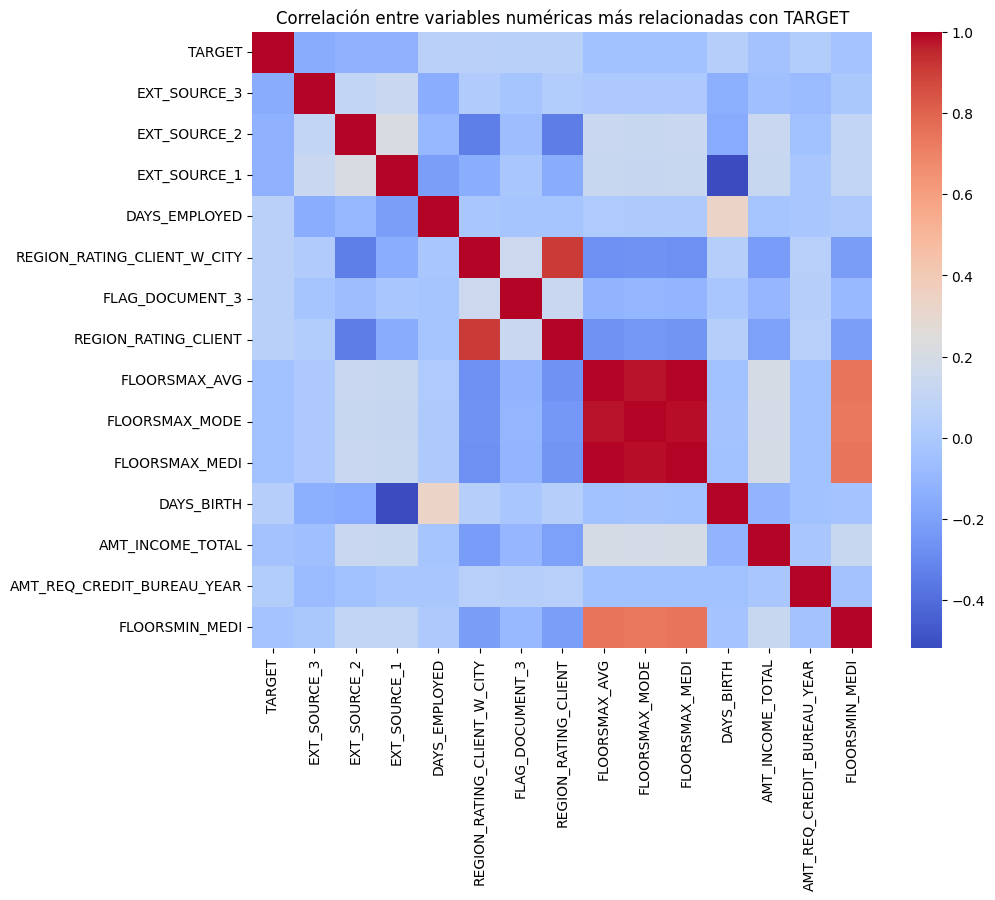

In [15]:
top_corr = corr_target.abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(10,8))
sns.heatmap(data[top_corr].corr(), annot=False, cmap="coolwarm")
plt.title("Correlación entre variables numéricas más relacionadas con TARGET")
plt.show()

## 2. Realizar el escalamiento multidimensional de los datos y realizar la 
interpretación correspondiente.

## 3. Crear una clase en python 
que reciba como parámetro el dataset y los  
transformadores correspondientes y pueda realizar el preprocesamiento de las 
variables. La clase debe interpretar la función fit que calibra los  
transformadores y la función transform que realiza la transformación  
propiamente dicha. 